
Matchwise data of Tata IPL 2022 ( IPL Season 15)

In [424]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [425]:
df1 = pd.read_csv('/content/Book_ipl22_ver_33.csv')

In [426]:
df1.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [427]:
df1.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


In [428]:
type(df1)

pandas.core.frame.DataFrame

In [429]:
df1.dtypes

,0
match_id,int64
date,object
venue,object
team1,object
team2,object
stage,object
toss_winner,object
toss_decision,object
first_ings_score,int64
first_ings_wkts,int64


Checking if there are any values that are not unique .
For example : There are two teams ,one is Lucknow Super Giants and the

In [430]:
df1['match_winner'].unique()

array(['Kolkata', 'Delhi', 'Punjab', 'Gujarat', 'Rajasthan', 'Banglore',
       'Lucknow', 'Hyderabad', 'Chennai', 'Mumbai'], dtype=object)

In [431]:
df1['toss_winner'].unique()

array(['Kolkata', 'Delhi', 'Punjab', 'Gujarat', 'Hyderabad', 'Banglore',
       'Lucknow', 'Mumbai', 'Chennai', 'Rajasthan'], dtype=object)

In [432]:
df1['team1'].unique()

array(['Chennai', 'Delhi', 'Banglore', 'Gujarat', 'Hyderabad', 'Kolkata',
       'Mumbai', 'Lucknow', 'Punjab'], dtype=object)

In [433]:
df1['toss_decision'].unique()

array(['Field', 'Bat'], dtype=object)

In [434]:
df1['stage'].unique()

array(['Group', 'Playoff', 'Final'], dtype=object)

In [435]:
df1['venue'].unique()

array(['Wankhede Stadium, Mumbai', 'Brabourne Stadium, Mumbai',
       'Dr DY Patil Sports Academy, Mumbai',
       'Maharashtra Cricket Association Stadium,Pune',
       'Eden Gardens, Kolkata', 'Narendra Modi Stadium, Ahmedabad'],
      dtype=object)

Now we will do feature selection because without it Data Leakage might happen i.e Data leakage means using information in your model that would not be available at the time of prediction in real life.

In [436]:
df = df1[['team1','team2','stage','toss_winner','toss_decision','match_winner','venue']]

In [437]:
type(df)

pandas.core.frame.DataFrame

In [438]:
df.head()

,team1,team2,stage,toss_winner,toss_decision,match_winner,venue
0,Chennai,Kolkata,Group,Kolkata,Field,Kolkata,"Wankhede Stadium, Mumbai"
1,Delhi,Mumbai,Group,Delhi,Field,Delhi,"Brabourne Stadium, Mumbai"
2,Banglore,Punjab,Group,Punjab,Field,Punjab,"Dr DY Patil Sports Academy, Mumbai"
3,Gujarat,Lucknow,Group,Gujarat,Field,Gujarat,"Wankhede Stadium, Mumbai"
4,Hyderabad,Rajasthan,Group,Hyderabad,Field,Rajasthan,"Maharashtra Cricket Association Stadium,Pune"


In [439]:
import plotly.express as px

Which team has won the most matches overall

In [440]:
print(df['match_winner'].value_counts())

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64


In [441]:
match_winner_counts_df = df['match_winner'].value_counts().reset_index()
barChart = px.bar(match_winner_counts_df, x = 'match_winner', y = 'count', title = 'Which team has won the most matches overall')
barChart.show()

In [442]:
df.columns


Index(['team1', 'team2', 'stage', 'toss_winner', 'toss_decision',
       'match_winner', 'venue'],
      dtype='object')

In [443]:
def winner(x):
  if x['toss_winner'] == x['match_winner']:
    return "yes"
  else:
    return "No"

df['toss_help'] = df.apply(winner,axis = 1)

/tmp/ipykernel_5338/4015226032.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [444]:
df['toss_help'].value_counts().reset_index(name = "count")

,toss_help,count
0,No,38
1,yes,36


In [445]:
df3 = df['toss_help'].value_counts().reset_index()
barPlot3 = px.bar(df3 , x = 'toss_help' ,y = 'count',title = 'Toss does not significantly impact match outcome')
barPlot3.show()

In [446]:
df4 = df['venue'].value_counts().reset_index().sort_values(by = 'count')

In [447]:
barPlot4 = px.bar(df4 , y = 'venue' , x = 'count',title = 'Which venues host the most matches')
barPlot4.show()

In [448]:
outcome = df.groupby(['toss_help','toss_decision']).size().reset_index(name = 'count')


In [449]:
outcome


,toss_help,toss_decision,count
0,No,Bat,8
1,No,Field,30
2,yes,Bat,7
3,yes,Field,29


In [450]:
barplot4 = px.bar(outcome , x = 'toss_decision' , y = 'count' , color = 'toss_help',title = ' Does Toss Decision (Bat/Field) Affect the Outcome?')
barplot4.show()

Feature engineering

In [451]:
df.head()

,team1,team2,stage,toss_winner,toss_decision,match_winner,venue,toss_help
0,Chennai,Kolkata,Group,Kolkata,Field,Kolkata,"Wankhede Stadium, Mumbai",yes
1,Delhi,Mumbai,Group,Delhi,Field,Delhi,"Brabourne Stadium, Mumbai",yes
2,Banglore,Punjab,Group,Punjab,Field,Punjab,"Dr DY Patil Sports Academy, Mumbai",yes
3,Gujarat,Lucknow,Group,Gujarat,Field,Gujarat,"Wankhede Stadium, Mumbai",yes
4,Hyderabad,Rajasthan,Group,Hyderabad,Field,Rajasthan,"Maharashtra Cricket Association Stadium,Pune",No


In [452]:
from sklearn.preprocessing import LabelEncoder

In [453]:
le = LabelEncoder()

In [454]:
le.fit(pd.concat([df['team1'], df['team2'], df['toss_winner'], df['match_winner']]))
df['team1'] = le.transform(df['team1'])
df['team2'] = le.transform(df['team2'])
df['match_winner'] = le.transform(df['match_winner'])
df['toss_winner'] = le.transform(df['toss_winner'])

/tmp/ipykernel_5338/903852743.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5338/903852743.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5338/903852743.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5338/90

In [455]:
le_venue = LabelEncoder()
le_stage = LabelEncoder()
le_toss = LabelEncoder()
df['venue'] = le_venue.fit_transform(df['venue'])
df['stage'] = le_stage.fit_transform(df['stage'])
df['toss_decision'] = le_toss.fit_transform(df['toss_decision'])

/tmp/ipykernel_5338/2666298516.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5338/2666298516.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5338/2666298516.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [456]:
df.head()

,team1,team2,stage,toss_winner,toss_decision,match_winner,venue,toss_help
0,1,5,1,5,1,5,5,yes
1,2,7,1,2,1,2,0,yes
2,0,8,1,8,1,8,1,yes
3,3,6,1,3,1,3,5,yes
4,4,9,1,4,1,9,3,No


In [457]:
X = df[['team1','team2','stage','toss_winner','toss_decision','venue']]
Y = df['match_winner']

In [458]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [459]:
print(x_train.shape)
print(x_test.shape)

(59, 6)
(15, 6)


In [460]:
from sklearn.ensemble import RandomForestClassifier

In [461]:
model = RandomForestClassifier(n_estimators = 100 ,random_state = 42)
model.fit(x_train,y_train)
y_predRF = model.predict(x_test)

In [462]:
from sklearn.metrics import accuracy_score

In [463]:
accuracyRF = accuracy_score(y_test,y_predRF)
print(accuracyRF*100)

33.33333333333333


In [464]:
from sklearn.neighbors import KNeighborsClassifier

In [465]:
knn = KNeighborsClassifier(n_neighbors=3)

In [466]:
knn.fit(x_train,y_train)
y_predknn = knn.predict(x_test)
accuracyknn = accuracy_score(y_test,y_predknn)
print(accuracyknn*100)

40.0


Tested hypter parameter tuning and we can see that n_neighbors = 3 gives the best accuracy


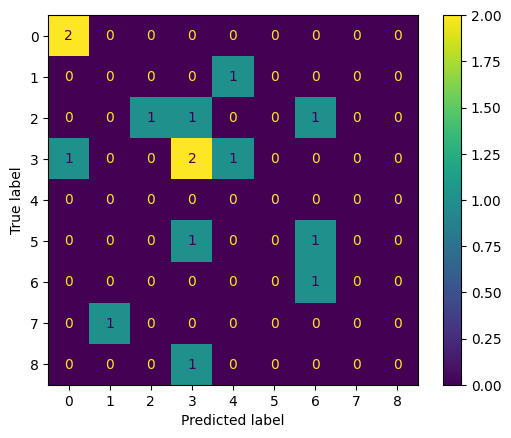

In [467]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test,y_predknn)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

In [468]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

fig = px.bar(importance_df, x='Feature', y='Importance',
             title='Feature Importance')
fig.show()

In [469]:
le.transform(['Chennai','Mumbai'])
le_venue.transform(['Wankhede Stadium, Mumbai'])
le_toss.transform(['Field'])
le_stage.transform(['Group'])

array([1])

In [470]:
print(le.classes_)
print(le_venue.classes_)
print(le_toss.classes_)
print(le_stage.classes_)

['Banglore' 'Chennai' 'Delhi' 'Gujarat' 'Hyderabad' 'Kolkata' 'Lucknow'
 'Mumbai' 'Punjab' 'Rajasthan']
['Brabourne Stadium, Mumbai' 'Dr DY Patil Sports Academy, Mumbai'
 'Eden Gardens, Kolkata' 'Maharashtra Cricket Association Stadium,Pune'
 'Narendra Modi Stadium, Ahmedabad' 'Wankhede Stadium, Mumbai']
['Bat' 'Field']
['Final' 'Group' 'Playoff']


In [471]:
X.head()

,team1,team2,stage,toss_winner,toss_decision,venue
0,1,5,1,5,1,5
1,2,7,1,2,1,0
2,0,8,1,8,1,1
3,3,6,1,3,1,5
4,4,9,1,4,1,3


In [472]:
for i, team in enumerate(le.classes_):
    print(f"{team} = {i}")

Banglore = 0
Chennai = 1
Delhi = 2
Gujarat = 3
Hyderabad = 4
Kolkata = 5
Lucknow = 6
Mumbai = 7
Punjab = 8
Rajasthan = 9


Team Encoding:
Bangalore = 0, Chennai = 1, Delhi = 2, Gujarat = 3,
Hyderabad = 4, Kolkata = 5, Lucknow = 6, Mumbai = 7,
Punjab = 8, Rajasthan = 9

Venue Encoding:
Brabourne Stadium = 0, Dr DY Patil = 1, Eden Gardens = 2,
Maharashtra CA Stadium = 3, Narendra Modi Stadium = 4,
Wankhede Stadium = 5

Toss Decision: Bat = 0, Field = 1
Stage: Final = 0, Group = 1, Playoff = 2

Gujarat vs Punjab

In [473]:
trial_df = pd.DataFrame({
    'team1': [9],
    'team2': [3],
    'stage': [0],
    'toss_winner': [8],
    'toss_decision': [0],
    'venue': [4]
})

according to RandomForest

In [474]:
predictionRF = model.predict(trial_df)

In [475]:
le.inverse_transform(predictionRF)

array(['Gujarat'], dtype=object)

In [476]:
predictionKnn = knn.predict(trial_df)
le.inverse_transform(predictionKnn)

array(['Gujarat'], dtype=object)